In [1]:
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

In [2]:
path_1 = ('data/olist_customers_dataset.csv')
path_2 = ('data/olist_order_items_dataset.csv')
path_3 = ('data/olist_orders_dataset.csv')

In [3]:
customers_df = pd.read_csv(path_1)
customers_df.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
order_items_df = pd.read_csv(path_2)
order_items_df ['shipping_limit_date'] = pd.to_datetime(order_items_df ['shipping_limit_date'] )
order_items_df.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
orders_df = pd.read_csv(path_3)
orders_df ['order_purchase_timestamp'] = pd.to_datetime(orders_df ['order_purchase_timestamp'] )
orders_df ['order_approved_at'] = pd.to_datetime(orders_df ['order_approved_at'] )
orders_df ['order_delivered_carrier_date'] = pd.to_datetime(orders_df ['order_delivered_carrier_date'] )
orders_df ['order_delivered_customer_date'] = pd.to_datetime(orders_df ['order_delivered_customer_date'] )
orders_df ['order_estimated_delivery_date'] = pd.to_datetime(orders_df ['order_estimated_delivery_date'] )
orders_df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


# Оценка месячного retention в оформление заказа с помощью когортного анализа

Будем рассматриваь заказы со статусом delivered, так как это гарантирует нам, что заказ дейстительно состоялся со стороны пользователя. Для retention берём order_purchase_timestamp (дату создания заказа), так как нам нужно увидеть поведение пользователя, когда он принял решение о покупке.

In [7]:
# # Подтягиваем customer_unique_id, так как customer_id в Olist уникален для каждого заказа
# и не позволяет отследить повторные покупки одного пользователя

orders_df_copy = orders_df.query("order_status == 'delivered'").copy()
orders_df_copy = orders_df_copy.merge(
    customers_df[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left')

In [8]:
orders_df_copy.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6


In [9]:
orders_df_copy['order_period'] = orders_df_copy['order_purchase_timestamp'].dt.to_period('M')
orders_df_copy['order_period_day'] = orders_df_copy['order_purchase_timestamp'].dt.to_period('D')

# Присваиваем когорты на основе даты первого действия для каждого пользователя
orders_df_copy['cohort'] = orders_df_copy.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
orders_df_copy['cohort_day'] = orders_df_copy.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

#Рассчитываем номер периода в днях (месячные периоды, деля на 30)
orders_df_copy['period_number_month'] = np.floor((orders_df_copy.order_period_day - orders_df_copy.cohort_day).apply(attrgetter('n')) / 30)

In [10]:
df_cohort = orders_df_copy.groupby(['cohort', 'period_number_month']).agg(
    n_customers=('customer_unique_id', 'nunique')
).reset_index()

In [11]:
df_cohort.head()

,cohort,period_number_month,n_customers
0,2016-09,0.0,1
1,2016-10,0.0,262
2,2016-10,6.0,1
3,2016-10,9.0,1
4,2016-10,11.0,1


In [12]:
# Создаем сводную таблицу для когортного анализа
cohort_pivot = df_cohort.pivot_table(
    index='cohort',
    columns='period_number_month',
    values='n_customers'
)

cohort_size = cohort_pivot.iloc[:, 0] 
# Вычисляем коэффициенты удержания, деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

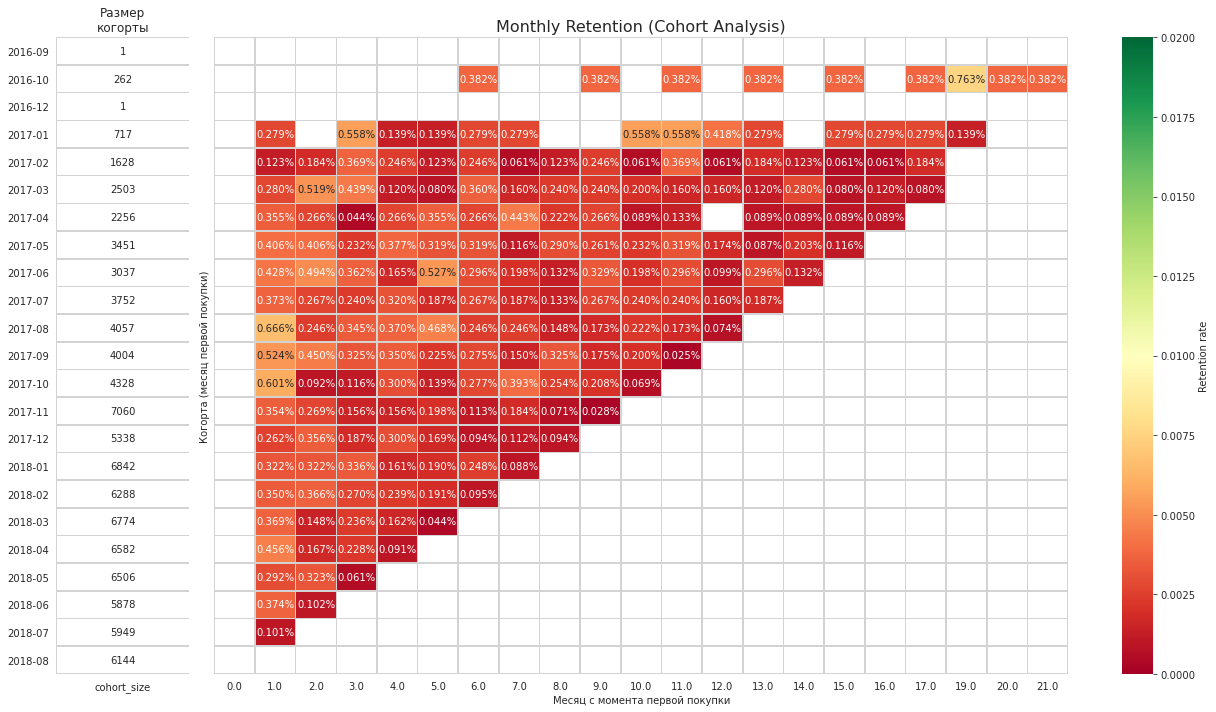

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

retention_vis = retention_matrix.copy()

retention_colors = retention_vis.copy()
retention_colors[0] = np.nan
annot_data = retention_vis.applymap(lambda x: f"{x:.3%}" if pd.notnull(x) else "")

with sns.axes_style("white"):
    fig, ax = plt.subplots(
        1, 2,
        figsize=(18, 10),
        sharey=True,
        gridspec_kw={'width_ratios': [1.5, 12]}
    )


    sns.heatmap(
        retention_colors,
        annot=annot_data,
        fmt="",
        cmap="RdYlGn",
        vmin=0,
        vmax=0.02,
        linewidths=0.5,
        linecolor='lightgray',
        cbar_kws={'label': 'Retention rate'},
        ax=ax[1]
    )

    ax[1].set_title('Monthly Retention (Cohort Analysis)', fontsize=16)
    ax[1].set_xlabel('Месяц с момента первой покупки')
    ax[1].set_ylabel('Когорта (месяц первой покупки)')

    # Размер когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])

    sns.heatmap(
        cohort_size_df,
        annot=True,
        fmt='g',
        cmap=white_cmap,
        cbar=False,
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax[0]
    )

    ax[0].set_title('Размер\nкогорты', fontsize=12)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')

    plt.tight_layout()
    plt.show()

Можем сделать вывод, что retention очень низкий после первого месяца. Большенство пользователей делают один  заказ и больше не возвращаются

проанализируем, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)

In [14]:
median_retention_month1 = retention_matrix[1].median()
print(f"Медианный retention 1-го месяца: {median_retention_month1:.3%}")

Медианный retention 1-го месяца: 0.355%


Возрат клиентов после первого месяца 0,355%. Можем сделать вывод, что лояльность очень низкая, практически не совершаются повторные покупки

In [15]:
best_cohort_month3 = retention_matrix[3].idxmax()
best_value_month3 = retention_matrix[3].max()
print(f"Когорта с наибольшим retention на 3-й месяц: {best_cohort_month3}")
print(f"Retention: {best_value_month3:.3%}")

Когорта с наибольшим retention на 3-й месяц: 2017-01
Retention: 0.558%


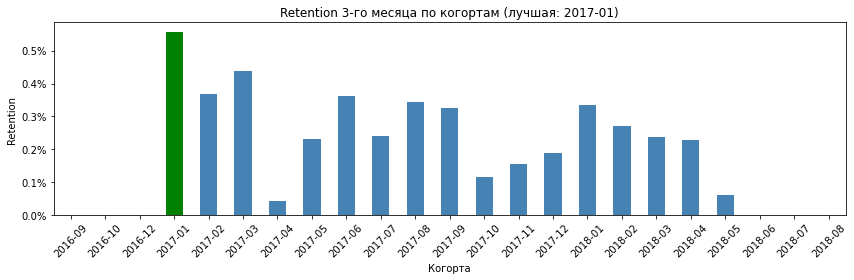

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['green' if x == best_cohort_month3 else 'steelblue' 
          for x in retention_matrix[3].index]
retention_matrix[3].plot(kind='bar', ax=ax, color=colors)
ax.set_title(f'Retention 3-го месяца по когортам (лучшая: {best_cohort_month3})')
ax.set_xlabel('Когорта')
ax.set_ylabel('Retention')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Определим, существует ли product/market fit у маркетплейса.

Для того, чтобы понять, существует ли у продукта PMF будем делать выводы на основе стабилизации retention. 

In [17]:
# Посчитаем retention по каждому месяцу по всем когортам
avg_retention = retention_matrix.mean()

In [18]:
avg_retention.mean()

0.05000266580481185

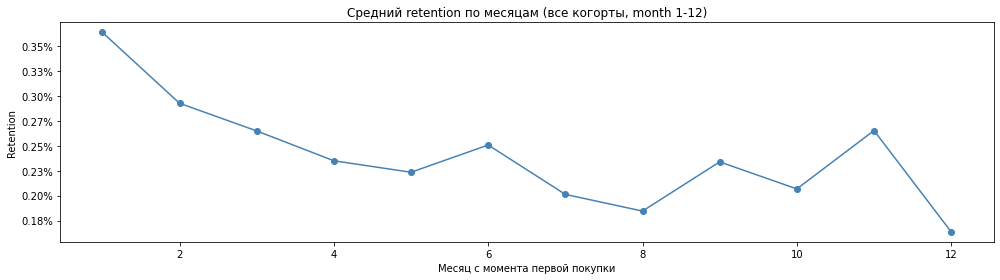

In [19]:
# Оставляем только первые 12 месяцев
avg_retention = retention_matrix.loc[:, 1:12].mean()

fig, ax = plt.subplots(figsize=(14, 4))
avg_retention.plot(kind='line', ax=ax, marker='o', color='steelblue')
ax.set_title('Средний retention по месяцам (все когорты, month 1-12)')
ax.set_xlabel('Месяц с момента первой покупки')
ax.set_ylabel('Retention')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
plt.tight_layout()
plt.show()

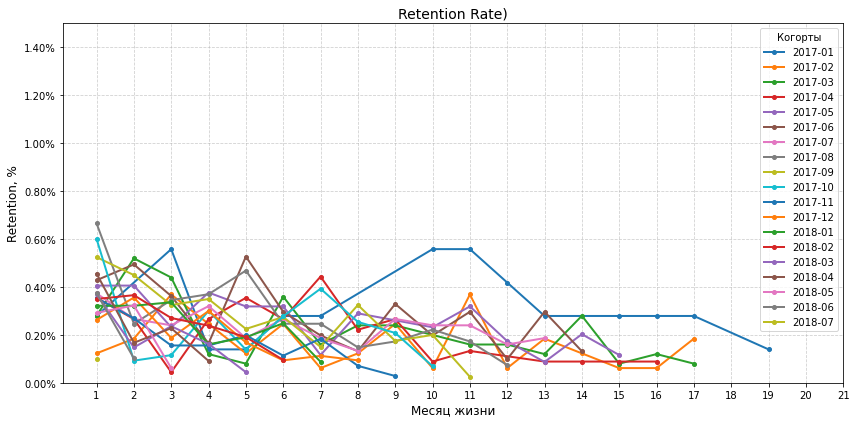

In [20]:
retention_matrix.index = retention_matrix.index.astype(str)
target_cohorts = [c for c in retention_matrix.index if '2017-01' <= c <= '2018-07']

fig, ax = plt.subplots(figsize=(12, 6))

for cohort in target_cohorts:
    cohort_series = retention_matrix.loc[cohort, 1.0:].dropna()
    ax.plot(
        cohort_series.index.astype(int),  
        cohort_series.values * 100,
        label=cohort,
        marker='o',
        markersize=4,
        linewidth=2
    )

ax.set_title('Retention Rate)', fontsize=14)
ax.set_xlabel('Месяц жизни', fontsize=12)
ax.set_ylabel('Retention, %', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}%'))
ax.set_ylim(0, 1.5)
ax.set_xticks(range(1, int(retention_matrix.columns.max()) + 1))
ax.legend(title='Когорты')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

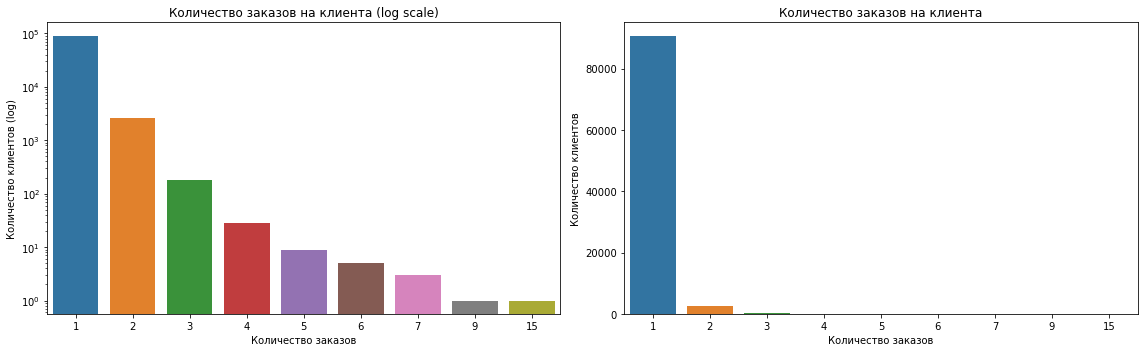

In [21]:
count_orders = orders_df_copy.groupby("customer_unique_id", as_index=False).agg(
    n_orders=('order_purchase_timestamp', 'count')
)
count_orders = count_orders.groupby("n_orders", as_index=False).agg(
    n_customers=('customer_unique_id', 'count')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=count_orders, x='n_orders', y='n_customers', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Количество заказов на клиента (log scale)')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Количество клиентов (log)')

sns.barplot(data=count_orders, x='n_orders', y='n_customers', ax=axes[1])
axes[1].set_title('Количество заказов на клиента')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество клиентов')

plt.tight_layout()
plt.show()

In [22]:
share = count_orders.query("n_orders == 1")['n_customers'].sum() / count_orders['n_customers'].sum() * 100
print(f"{share:.1f}% клиентов совершают только один заказ")

97.0% клиентов совершают только один заказ


In [23]:
cohort_size_mean = cohort_size_df['cohort_size'].mean()
print(f"Количество привлеченных клиентов в среднем в месяц: {cohort_size_mean:.1f}")

Количество привлеченных клиентов в среднем в месяц: 4059.0


---

Вывод: **Product/market fit** у продукта **отсутвует**. Возрат клиентов после первого месяца в продукт **0,355%**. Доля клиентов, которые совершают только **один заказ 97%**. **Маштабирование** без изменений проудкта приведет **к убыткам**, так как продукт не создает достаточной ценности для потребителя. 

Видим, что с каждый месяц количество клиентов которые начинают первый раз использовать наш продукт увеличивается, но не остаются в продукте, как уже было выяснено ранее. Большенство пользователей делают заказ только один раз и **покидают продукт.** При этом в продукт привлекается около **4059 клиентов в месяц**. На жанном этапе нужно повысить **удержание клиентов** в продукте.

Возможные причины: 
1. На маркетплейсе продаются довары не каждодневного использования (мебель, техника)
2. Отсутвие системы лояльности (клиент предпочтет другой сервис с бонусами за покупки, не будет больше использовать наш маркетплейс, предпочтет другой)
3. Товары низкого качества
4. Долгая доставка или же доставка с задержкой
5. Маленькая товарная матрица, нужных товаров нет на остатках. из за чего заказ отменяется

# 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

**Метрика 1 — GMV (Gross Merchandise Value)**
Суммарная стоимость всех доставленных заказов в месяц. Отражает реальный объём денег который проходит через маркетплейс — основной индикатор роста бизнеса. Растёт GMV — платформа привлекает больше покупок.

**Метрика 2 — MAU (Monthly Active Users)**
Количество уникальных покупателей с доставленным заказом в месяц. Показывает реальный размер аудитории которой продукт доставляет ценность — не просто зарегистрированных пользователей, а тех кто фактически получил товар.
CAC (Customer Acquisition Cost) — стоимость привлечения одного нового пользователя по каналам маркетинга. 

**Метрика 3 — Новые пользователи в месяц**
Количество покупателей совершивших первый заказ в данном месяце. Отражает эффективность привлечения — насколько маркетплейс интересен новой аудитории. На имеющихся данных можно посчитать через минимальную дату заказа по каждому пользователю.

**Метрика 4 — Retention Month 1**
Доля пользователей вернувшихся и сделавших повторный заказ в следующем месяце после первой покупки. Отражает вовлечённость — насколько продукт мотивирует возвращаться. Уже рассчитана в рамках когортного анализа: медианный retention составил 0.51%.

**Метрика 5 — LTV (Lifetime Value)**
Средняя суммарная выручка с одного покупателя за всё время. Отражает денежную ценность удержанного пользователя — сколько денег в среднем приносит один лояльный клиент за период использования продукта.

In [84]:
# подготовка данных
df_met = orders_df.merge(
    customers_df[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left')
orders_amount = order_items_df.groupby("order_id", as_index=False).agg({'price': 'sum'})
df_met = df_met.merge(orders_amount[['order_id', 'price']],
    on='order_id',
    how='left')

df_met.query("order_status == 'delivered'")
df_met['month'] = df_met['order_purchase_timestamp'].dt.to_period('M')

In [85]:
#Метрика 1 — GMV (Gross Merchandise Value)
GMV = df_met.query("order_status == 'delivered'").groupby("month", as_index=False).agg({'price': 'sum'})
GMV['month'] = GMV['month'].astype(str)

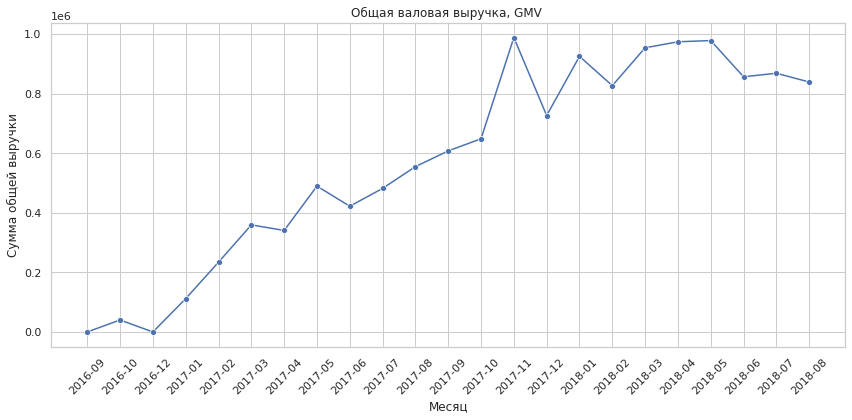

In [87]:
#Построение графика: Метрика 1 — GMV (Gross Merchandise Value)**

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Установка стиля графика
sns.lineplot(x='month', y='price', data=GMV, marker='o')  # Добавление маркеров на линии
plt.xticks(rotation=45)  # Поворот меток по оси X для лучшей читаемости
plt.title('Общая валовая выручка, GMV ')
plt.xlabel('Месяц')
plt.ylabel('Сумма общей выручки')
plt.grid(True)  # Включение сетки
plt.tight_layout()  # Автоматическая подгонка элементов графика
plt.show()

----

In [114]:
# Метрика 2 — MAU (Monthly Active Users) с гранулярностью в месяц
MAU = df_met.query("order_status == 'delivered'").groupby("month", as_index=False).agg({'customer_unique_id': 'nunique'}).rename(columns = {'customer_unique_id': 'MAU'})
MAU['month'] = MAU['month'].astype(str)

In [1]:
 # Построение графика Метрика 2 — MAU (Monthly Active Users)
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Установка стиля графика
sns.lineplot(x='month', y='MAU', data=MAU, marker='o')  # Добавление маркеров на линии
plt.xticks(rotation=45)  # Поворот меток по оси X для лучшей читаемости
plt.title('MAU')
plt.xlabel('Месяц')
plt.ylabel('Кол во активных пользователей')
plt.grid(True)  # Включение сетки
plt.tight_layout()  # Автоматическая подгонка элементов графика
plt.show()

NameError: name 'plt' is not defined

----

In [97]:
# Новые пользователи в месяц
first_orders = (df_met
                .query("order_status == 'delivered'")
                .groupby('customer_unique_id')['order_purchase_timestamp']
                .min()
                .dt.to_period('M')
                .astype(str)
)

new_users = (first_orders
             .value_counts()
             .sort_index()
             .reset_index()
             .rename(columns={'index': 'month', 'order_purchase_timestamp': 'new_users'})
)
new_users
new_users['month'] = new_users['month'].astype(str)

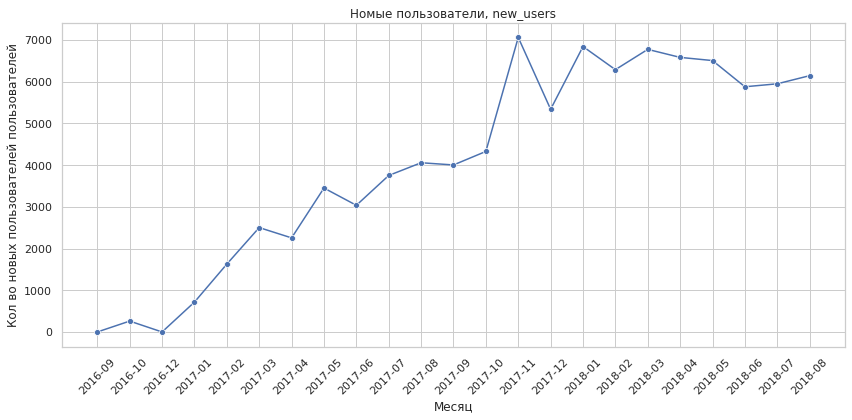

In [100]:
 # Построение графика  Новые пользователи в месяц
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Установка стиля графика
sns.lineplot(x='month', y='new_users', data=new_users, marker='o')  # Добавление маркеров на линии
plt.xticks(rotation=45)  # Поворот меток по оси X для лучшей читаемости
plt.title('Номые пользователи, new_users')
plt.xlabel('Месяц')
plt.ylabel('Кол во новых пользователей пользователей')
plt.grid(True)  # Включение сетки
plt.tight_layout()  # Автоматическая подгонка элементов графика
plt.show()

Метрика 3 — заинтересованность новых клиентов в продукте

В качестве метрики предлагается рассмотреть три показателя:

CAC (Customer Acquisition Cost) — стоимость привлечения одного нового пользователя по каналам маркетинга. Отражает эффективность привлечения новой аудитории. Для расчёта необходимы данные о маркетинговых расходах в разбивке по каналам, которые отсутствуют в датасете.

Конверсия из первого касания в покупку : доля пользователей которые после первого взаимодействия с платформой (просмотр, добавление в корзину) совершили заказ. Для расчёта необходимы данные о поведении пользователей до оформления заказа — события сессий и корзины, которые в датасете отсутствуют.

Количество новых пользователей по каналам привлечения: абсолютное число пользователей совершивших первый заказ в разбивке по источнику трафика. Для расчёта необходимы UTM-метки или данные атрибуции, которые в датасете отсутствуют.


---

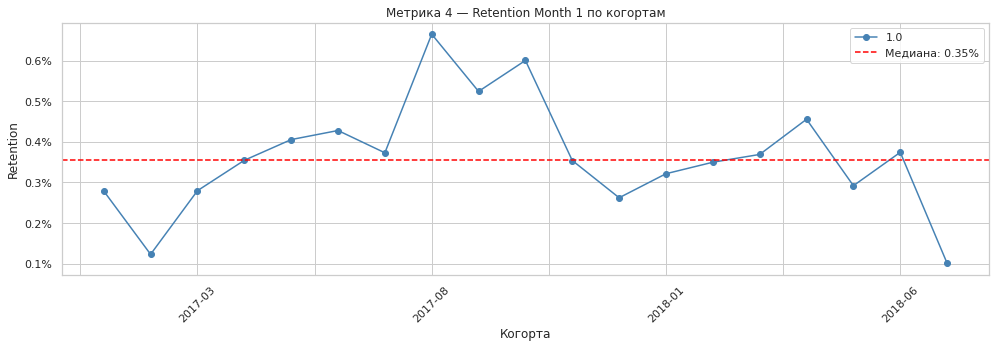

In [110]:
# Метрика 4 — Retention Month 1
fig, ax = plt.subplots(figsize=(14, 5))
retention_matrix[1].astype(float).plot(kind='line', ax=ax, marker='o', color='steelblue')
ax.axhline(y=median_retention_month1, color='red', linestyle='--',
           label=f'Медиана: {median_retention_month1:.2%}')
ax.set_title('Метрика 4 — Retention Month 1 по когортам')
ax.set_xlabel('Когорта')
ax.set_ylabel('Retention')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

----

In [105]:
# Метрика 5 — LTV (средняя выручка с одного покупателя)
ltv = (orders_df_copy
       .query("order_status == 'delivered'")
       .merge(orders_amount, on='order_id', how='left')
       .groupby('customer_unique_id')['price']
       .sum()
       .mean()
)

print(f"LTV: {ltv:.2f} BRL")

LTV: 141.62 BRL


In [108]:
ltv_by_month = (orders_df
                .query("order_status == 'delivered'")
                .merge(orders_amount, on='order_id', how='left')
                .merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
                .groupby('customer_unique_id')
                .agg(
                    total_revenue=('price', 'sum'),
                    first_order=('order_purchase_timestamp', 'min')
                )
                .reset_index()
)

ltv_by_month['order_period'] = ltv_by_month['first_order'].dt.to_period('M').astype(str)

ltv_monthly = ltv_by_month.groupby('order_period')['total_revenue'].mean().reset_index()
ltv_monthly.rename(columns={'total_revenue': 'LTV'}, inplace=True)
ltv_monthly['order_period'] = ltv_monthly['order_period'].astype(str)

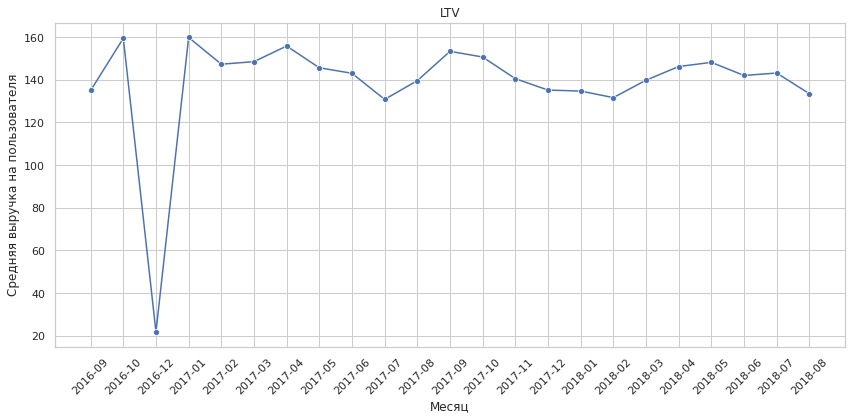

In [109]:
 # Построение графика Метрика 5 — LTV (средняя выручка с одного покупателя)
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Установка стиля графика
sns.lineplot(x='order_period', y='LTV', data=ltv_monthly, marker='o')  # Добавление маркеров на линии
plt.xticks(rotation=45)  # Поворот меток по оси X для лучшей читаемости
plt.title('LTV')
plt.xlabel('Месяц')
plt.ylabel('Средняя выручка на пользователя')
plt.grid(True)  # Включение сетки
plt.tight_layout()  # Автоматическая подгонка элементов графика
plt.show()

---

Основные метрики продукта 

No handles with labels found to put in legend.
No handles with labels found to put in legend.


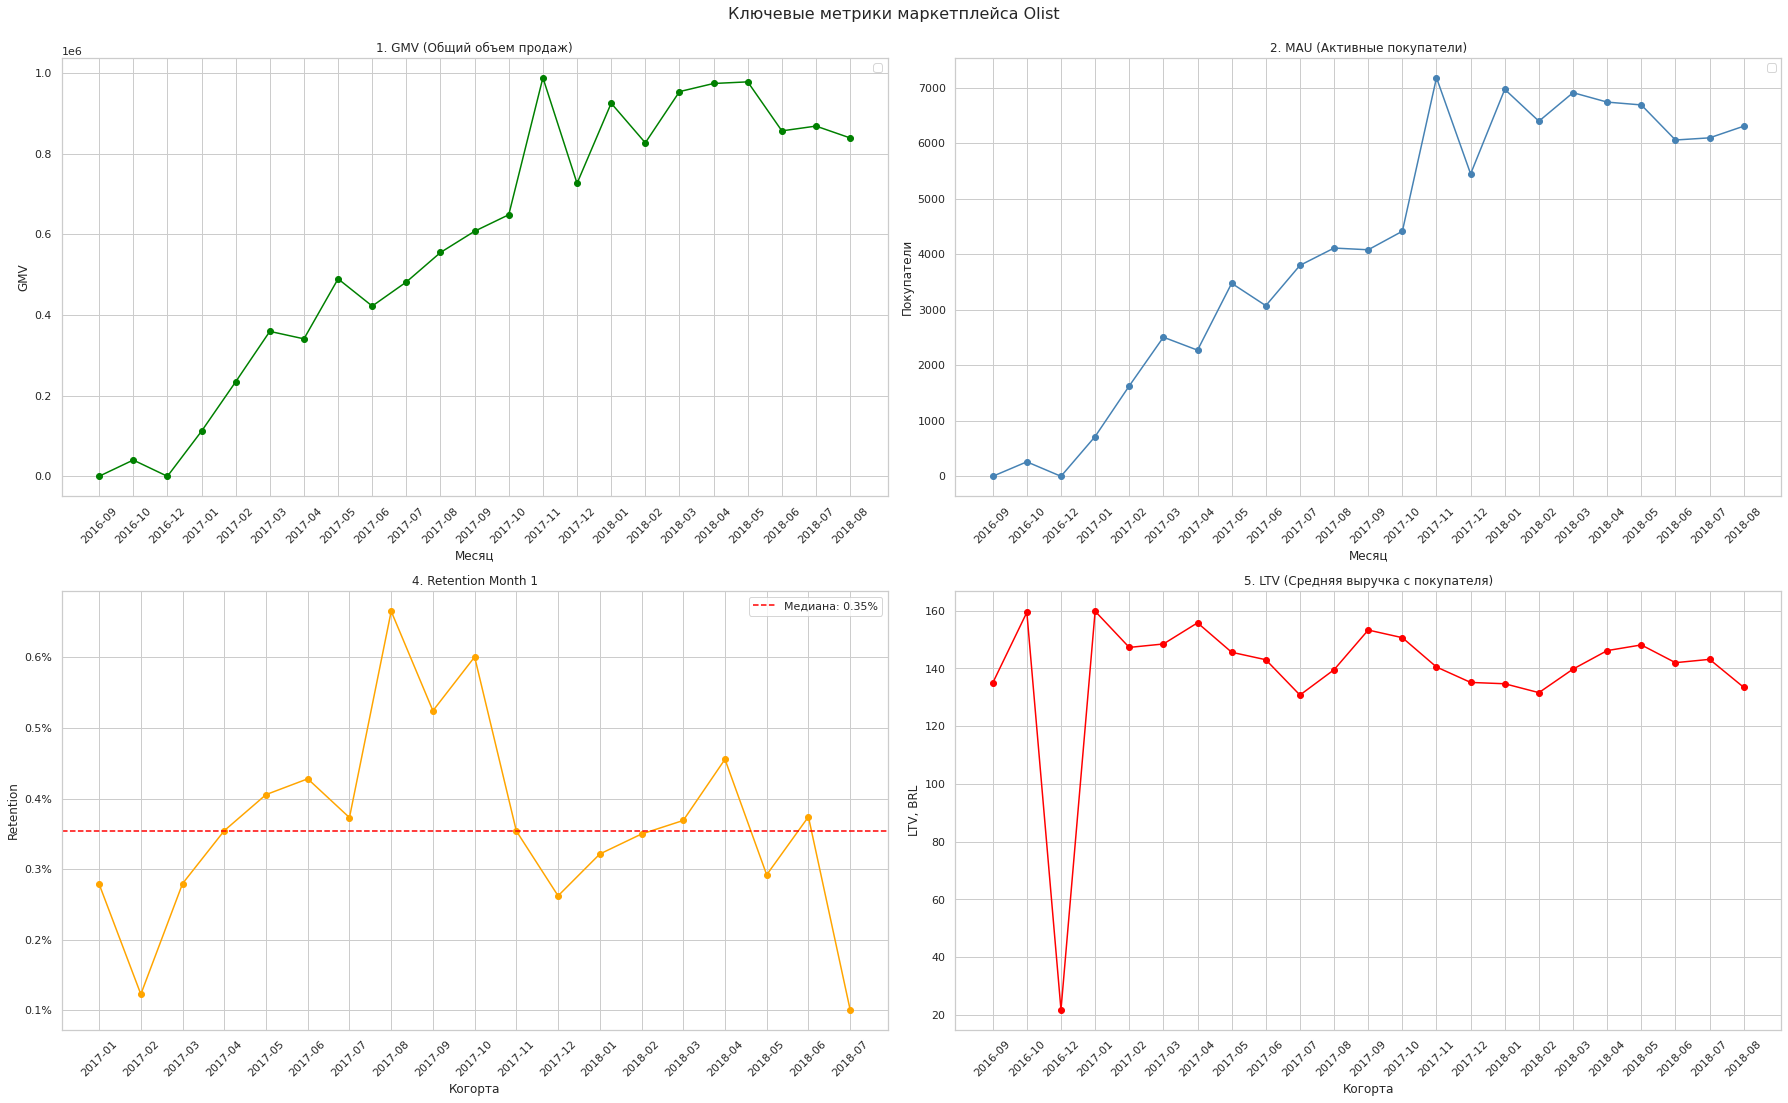

In [122]:
fig, axes = plt.subplots(2, 2, figsize=(25, 15))

# Метрика 1 — GMV
axes[0, 0].plot(GMV['month'], GMV['price'], marker='o', color= 'green' )
axes[0, 0].set_title('1. GMV (Общий объем продаж)')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('GMV')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# Метрика 2 — MAU
axes[0, 1].plot(MAU['month'], MAU['MAU'], marker='o', color='steelblue')
axes[0, 1].set_title('2. MAU (Активные покупатели)')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Покупатели')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Метрика 4 — Retention Month 1
retention_plot = retention_matrix[1].astype(float)
axes[1, 0].plot(retention_plot.index.astype(str), retention_plot.values, marker='o', color='orange')
axes[1, 0].axhline(y=median_retention_month1, color='red', linestyle='--',
                   label=f'Медиана: {median_retention_month1:.2%}')
axes[1, 0].set_title('4. Retention Month 1')
axes[1, 0].set_xlabel('Когорта')
axes[1, 0].set_ylabel('Retention')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# Метрика 5 — LTV
axes[1, 1].plot(ltv_monthly['order_period'], ltv_monthly['LTV'], marker='o', color='red')
axes[1, 1].set_title('5. LTV (Средняя выручка с покупателя)')
axes[1, 1].set_xlabel('Когорта')
axes[1, 1].set_ylabel('LTV, BRL')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Ключевые метрики маркетплейса Olist', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Проанализоровав данные метрики, можем сделать слледующие выводы:
Графики GMV и MAU имеют высокую корреляцию и практически совпадают, это происходит из за того пользователи совершают лишь один заказ. Очень хрупкая модель роста, так как при уменьшении количества привлеченных  клиентов в месяц общий обьем продаж упадет. 

Общий обьем продаж за все периоды растет, но это происходит из за того, что привлекается больше новой аудитории.
MAU показывает тенденцию роста по аналогичной причине.
Медианный retention 0.35%, что еще раз указывает на то, что пользователи совершают только одну покупку.
LTV очень низкий, обязательно нужно проанализировать CAC,  так как если затраты на привлечение большие, то бизнес будет убыточный


Все метрики еще раз демонтируют главную проблему: **низкая вовлеченность пользователей в продукт, отсутвие лоялости и низкий retention.**


# 3 основных гипотезы с помощью фреймворка ICE.

Для расчёта Impact возьмем данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

In [25]:
# Медианный retention 1го месяца
median_retention_month1

0.0035460992907801418

In [26]:
# Функция для перевода IMPACT в шкалу от 1 до 10 
def to_impact_score(value):
    boundaries = [50, 150, 350, 750, 1550, 3150, 6350, 12750, 25550, 51150]
    for score, bound in enumerate(boundaries, start=1):
        if value <= bound:
            return score
    return 10  # на случай если value > 51150

In [57]:
orders_df_full = orders_df.merge(
    customers_df[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

Гипотеза 1: 
Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

In [31]:
order_2017= orders_df_full.query("order_purchase_timestamp >='2017-06-01 00:00:00'")
canceled_orders = order_2017.query("order_status == 'canceled' or order_status == 'unavailable' ").order_id.nunique()

print(f"Количество отмененных заказов: {canceled_orders:.1f}, INPACT {to_impact_score(canceled_orders)}")

Количество отмененных заказов: 974.0, INPACT 5


---

Гипотеза 2: Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

In [42]:
#Рассмотрим сроки доставки продукта:
# Рассмотрим доставляют ли товары в срок. Для этоого сравним order_delivered_customer_date — время доставки заказа
# и order_estimated_delivery_date — обещанная дата доставки
order_2017 = orders_df.merge(
    customers_df[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
).query("order_purchase_timestamp >= '2017-06-01' and order_status == 'delivered'").copy()

order_2017['delivery_delay_days'] = (
    order_2017['order_delivered_customer_date'].dt.normalize() - 
    order_2017['order_estimated_delivery_date'].dt.normalize()
).dt.days

# > 0 — опоздание (доставили позже срока)
# < 0 — доставили раньше срока
# = 0 — день в день

def classify_delivery(days):
    if days > 0:
        return 'Опоздание'
    elif days < 0:
        return 'Раньше срока'
    else:
        return 'День в день'

order_2017['delivery_status'] = order_2017['delivery_delay_days'].apply(classify_delivery)

order_2017['delivery_status'].value_counts(normalize=True).mul(100).round(1)

mean_delay = order_2017['delivery_delay_days'].mean()
median_delay = order_2017['delivery_delay_days'].median()
late_share = (order_2017['delivery_status'] == 'Опоздание').mean() * 100

print(f"Средняя задержка доставки: {mean_delay:.1f} дней")
print(f"Медианная задержка доставки: {median_delay:.1f} дней")
print(f"Доля опозданий: {late_share:.1f}%")

Средняя задержка доставки: -11.4 дней
Медианная задержка доставки: -12.0 дней
Доля опозданий: 7.1%


In [45]:
delay_orders = order_2017.query("delivery_status == 'Опоздание'").order_id.nunique()
print (f"Количество опоздавших заказов: {delay_orders:.1f}, INPACT {to_impact_score(delay_orders*median_retention_month1)}")

Количество опоздавших заказов: 6087.0, INPACT 1


---

Гипотеза 3: Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [55]:
# Рассмотрим клиентов и количество их заказов
count_orders = order_2017.groupby("customer_unique_id", as_index=False).agg(n_orders=('order_purchase_timestamp', 'count'))
count_orders = count_orders.groupby("n_orders", as_index=False).agg(
    n_customers=('customer_unique_id', 'count'))
just_one_orders = count_orders.query("n_orders == 1").n_customers.sum()
print (f"Количество клиентов, сделавших один заказ: {just_one_orders:.1f}, INPACT {to_impact_score(just_one_orders*median_retention_month1)}")

Количество клиентов, сделавших один заказ: 80558.0, INPACT 3


---

Выберем гипотезу используя фреймворк ICE 

Гипотеза 1: I = 5; C = 8;  E = 6;    ICE = 240

Гипотеза 2: I = 1; C = 10; E = 4;    ICE = 40

Гипотеза 3: I = 3; C = 5;  E = 9;    ICE = 135
    
Вывод, **выбираем гипотезу 1:** исправление бага в процессинге
    Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

# Сформулируем нужные метрики, на которые ваша гипотеза должна повлиять.

**Гипотеза:**
    Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.
    
    
**Целевая метрика: количество delivered заказов в месяц**
Гипотеза утверждает что баг мешает заказам доходить до доставки. Значит успех — рост именно доставленных заказов.

**Прокси: доля canceled**
Если баг исправлен, отмены по техническим причинам должны сократиться. Это самый прямой сигнал что проблема устранена, данная метрика раньше других отразится в данных.

**Прокси: конверсия из оформленного в delivered**
Показывает какая доля заказов доходит до конца воронки. Если баг создавал утечку на этапе процессинга, конверсия должна вырасти.

**Guardrail: конверсия в оформление заказа**
Следим чтобы баг-фикс не затронул верхнюю часть воронки: пользователи должны по-прежнему без проблем оформлять заказы.

**Guardrail: среднее время обработки заказа**
Исправление бага не должно замедлить процессинг. Если заказы стали обрабатываться дольше, то создается побочный эффект который нивелирует пользу от фикса.

---

# Итог анализа. Формализация проблемы продукта. Точки роста

## Контекст и цель анализа

Датасет охватывает период с 2016 по 2018 год и содержит информацию о заказах, покупателях и товарах. Цель анализа — оценить состояние продукта, выявить ключевые проблемы и предложить первоочередную гипотезу для улучшения.

---

## Когортный retention

Для анализа использовались только заказы со статусом `delivered`(это гарантирует, что заказ фактически состоялся).

**Результат:** медианный retention первого месяца составил **0,35%**. Это означает, что из 1000 пользователей, сделавших первый заказ, в следующем месяце возвращается примерно 3–4 человека.

Тепловая карта когорт подтверждает: паттерн стабилен для всех когорт без исключений — резкое падение после первой покупки, повторные заказы носят единичный характер.


## Что мы обнаружили: главная проблема

**97% покупателей делают один заказ и больше не возвращаются.**

Это означает, что каждый месяц платформа тратит деньги на привлечение новых людей, но почти никто из них не становится постоянным клиентом. Бизнес растёт только за счёт новых покупателей — около 4 000 в месяц. Как только этот поток замедлится, выручка упадёт.

Для сравнения: у здорового маркетплейса хотя бы каждый пятый покупатель возвращается за повторной покупкой. У Olist — примерно 3–4 человека из тысячи.

Почему так происходит? Вероятные причины:
- На платформе продаётся много товаров, которые покупают раз в несколько лет (мебель, техника)
- Нет никаких бонусов или скидок за повторную покупку
- Часть заказов доставляется позже обещанной даты
- Встречаются товары низкого качества

---


## Product/Market Fit

PMF оценивался через три сигнала: уровень retention, стабилизацию кривой удержания и распределение заказов по пользователям.

**Вывод: PMF отсутствует.**

- Медианный retention M1 **0,35%** (норма для e-commerce с PMF от 20–30%)
- **97% пользователей** совершают ровно один заказ и не возвращаются
- Кривые retention всех когорт не стабилизируются — они падают до нуля
- Рост GMV и MAU объясняется исключительно притоком новых пользователей, а не удержанием

Возможные причины низкого retention: товары нечастого спроса (мебель, техника), отсутствие программы лояльности, задержки доставки, низкое качество части товаров.

**Масштабирование без изменений в продукте приведёт к убыткам**, поскольку рост целиком зависит от постоянного привлечения новой аудитории.

---

## Ключевые метрики

Для максимизации прибыли предлагается отслеживать пять метрик:

**GMV (Gross Merchandise Value)** — суммарная стоимость доставленных заказов в месяц. Основной индикатор роста бизнеса: растёт GMV — платформа генерирует больше оборота. За период наблюдается рост, но он полностью коррелирует с MAU — подтверждение модели «один пользователь = один заказ».

**MAU (Monthly Active Users)** — количество уникальных покупателей с доставленным заказом в месяц. Показывает реальный размер активной аудитории. Тренд восходящий, но рост обеспечен только новыми пользователями.

**Новые пользователи в месяц** — количество покупателей, совершивших первый заказ. Отражает эффективность привлечения. В среднем в месяц привлекается около 4 059 новых пользователей. (см. примечание)

**Retention M1** — доля пользователей, вернувшихся за повторным заказом в следующем месяце. Ключевой индикатор вовлечённости. Медианное значение — 0,35%, что критически мало.

**LTV (Lifetime Value)** — средняя суммарная выручка с одного покупателя. Отражает денежную ценность удержанного пользователя. При текущем retention LTV крайне низкий, и без данных о CAC невозможно оценить юнит-экономику — есть высокий риск убыточности по каждому привлечённому пользователю.

*Примечание:* метрики CAC, конверсия из первого касания и разбивка по каналам привлечения не могут быть рассчитаны из имеющегося датасета, для них необходимы данные о маркетинговых расходах и UTM-атрибуции.

---

## Выбор гипотезы по ICE

Рассмотрены три гипотезы. Базовый период с июня 2017 года. Impact рассчитан через количество дополнительных повторных заказов (используя медианный retention M1 = 0,35% как конверсию в повторный заказ), переведённое в шкалу 1–10.

**Гипотеза 1.** Исправление бага в системе процессинга заказов устранит отмены и увеличит количество доставленных заказов.
За период зафиксировано 625 отменённых и недоступных заказов.
I = 5 (625 заказов — умеренный прямой эффект), C = 8 (баг-фикс — техническая задача с понятным скоупом, реализуемая за 1–2 спринта), E = 6 (требует участия бэкенд-команды, но без внешних зависимостей). **ICE = 240.**

**Гипотеза 2.** Сокращение времени до отгрузки снизит количество опозданий и увеличит повторные заказы.
Доля опозданий — 9,4%, но конверсия задержанных заказов в повторные при retention 0,35% даёт минимальный прирост.
I = 1 (крайне низкий расчётный прирост заказов), C = 10 (данные о задержках есть, проблема подтверждена), E = 4 (требует операционных изменений и работы с продавцами). **ICE = 40.**

**Гипотеза 3.** Новый способ оплаты, конвертирующий разовых покупателей в повторных.
Количество пользователей с одним заказом — 23 762, расчётный прирост при retention 0,35% — около 83 заказов.
I = 3 (умеренный потенциал при высокой базе), C = 5 (неизвестно, является ли оплата барьером), E = 9 (продуктовая фича с понятным скоупом). **ICE = 135.**

**Выбрана гипотеза 1** с ICE = 240.

---

## Метрики для проверки гипотезы

**Целевая метрика: количество delivered заказов в месяц.**
Гипотеза утверждает, что баг мешает заказам доходить до доставки. Успех: рост именно доставленных заказов.

**Прокси метрика: доля canceled заказов.**
Если баг устранён, технические отмены должны сократиться. Это самый быстрый сигнал: метрика отреагирует раньше, чем вырастет delivered.

**Прокси метрика: конверсия из оформленного заказа в delivered.**
Показывает, какая доля заказов проходит всю воронку до конца. Если баг создавал утечку на этапе процессинга — конверсия должна вырасти.

**Guardrail метрика: конверсия в оформление заказа.**
Баг-фикс не должен затронуть верхнюю часть воронки. Если после релиза пользователи стали реже оформлять заказы — появился побочный эффект.

**Guardrail метрика: среднее время обработки заказа.**
Исправление бага не должно замедлить процессинг. Если заказы стали обрабатываться дольше, польза от фикса нивелируется ухудшением опыта.

---

## Итог

Продукт находится на этапе роста без удержания: аудитория увеличивается, но продукт не создаёт достаточной ценности для возврата пользователей. Ключевая проблема заключается в том, что **97% пользователей совершают только один заказ**, PMF не достигнут.

Первоочередная задача: снизить техническое трение при оформлении и обработке заказов. Устранение бага в процессинге (гипотеза 1) выбрано как наиболее реализуемое улучшение с прямым измеримым эффектом на доставленные заказы.

В долгосрочной перспективе для достижения PMF необходимо работать над повышением retention: программой лояльности, улучшением качества доставки и расширением товарной матрицы в категориях повседневного спроса.